In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import torch
from tqdm.auto import tqdm


/home/chapuissamuel/Documents/code/RT-Diffusion/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Simplest Conditional Diffusion Model on 1D Signals

Dans ce notebook, on passe du cas 0D scalaire au cas 1D discret : chaque exemple $x_0$ est un signal de 32 échantillons,
$$x_0 \in \mathbb{R}^{32}.$$

Le processus de diffusion ne change pas conceptuellement : on ajoute un bruit gaussien indépendant sur chaque composante du signal. La différence principale est que le réseau ne prédit plus un bruit scalaire, mais un vecteur de bruit de taille 32 conditionné par le temps de diffusion et le label.


# Création du Dataset

On construit deux familles conditionnelles de signaux 1D échantillonnés sur `SIGNAL_SIZE = 32` points.

- `y=0` : signaux dominés par un pic localisé vers la gauche et une composante basse fréquence.
- `y=1` : signaux dominés par un pic localisé vers la droite et une composante de fréquence plus élevée.

Le dataset a donc la forme `(N, 32)` au lieu de `(N, 1)`. La normalisation globale est importante : avec un DDPM à variance fixe, le bruit terminal est implicitement comparé à une loi normale centrée réduite composante par composante.


In [4]:
N = 50000
SIGNAL_SIZE = 32

COLORS = ["#1f77b4", "#f54f4c"]

# labels : 0 ou 1
labels = torch.randint(0, 2, (N,))
grid = torch.linspace(0, 1, SIGNAL_SIZE)

def gaussian_bump(x, center, width):
    return torch.exp(-0.5 * ((x - center) / width) ** 2)

# Paramètres aléatoires par signal.
amplitude = 0.8 + 0.4 * torch.rand(N, 1)
phase = 2 * np.pi * torch.rand(N, 1)
width = 0.06 + 0.03 * torch.rand(N, 1)
center = torch.where(
    labels[:, None] == 0,
    0.30 + 0.05 * torch.randn(N, 1),
    0.70 + 0.05 * torch.randn(N, 1),
).clamp(0.12, 0.88)
frequency = torch.where(
    labels[:, None] == 0,
    torch.full((N, 1), 1.0),
    torch.full((N, 1), 3.0),
)
sign = torch.where(
    labels[:, None] == 0,
    torch.full((N, 1), -1.0),
    torch.full((N, 1), 1.0),
)

bump = gaussian_bump(grid[None, :], center, width)
carrier = torch.sin(2 * np.pi * frequency * grid[None, :] + phase)
trend = 0.25 * torch.cos(2 * np.pi * grid[None, :])

raw_dataset = sign * amplitude * bump + 0.25 * carrier + trend
raw_dataset += 0.05 * torch.randn_like(raw_dataset)

# Normalisation globale pour que les coordonnées aient un ordre de grandeur compatible avec N(0, I).
signal_mean = raw_dataset.mean()
signal_std = raw_dataset.std()
dataset = (raw_dataset - signal_mean) / signal_std

print(dataset.shape) # [N, 32]
print(labels.shape)  # [N]
print(dataset.mean().item(), dataset.std().item())


torch.Size([50000, 32])
torch.Size([50000])
5.798340030338522e-09 1.0


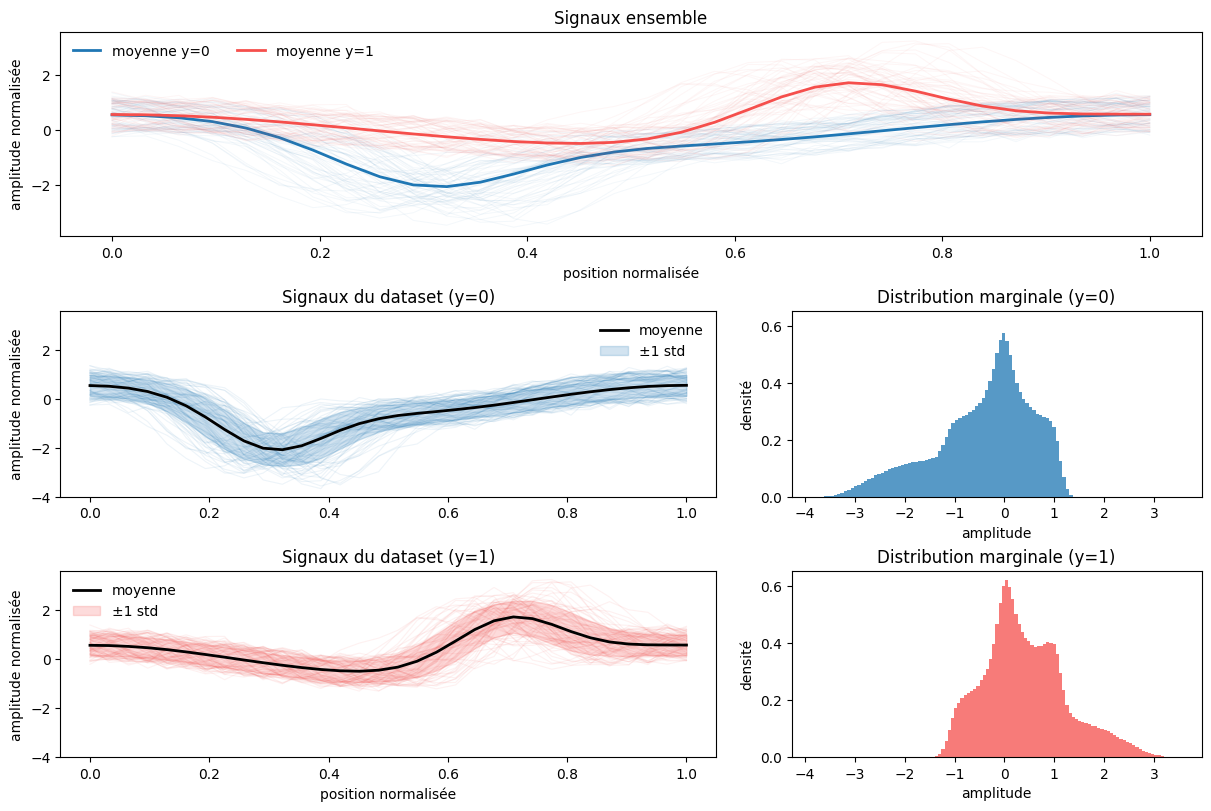

In [5]:
fig = plt.figure(figsize=(12, 8), constrained_layout=True)
gs = fig.add_gridspec(
    3,
    2,
    height_ratios=[1.1, 1.0, 1.0],
    width_ratios=[1.6, 1.0],
)

ax_all = fig.add_subplot(gs[0, :])
ax_signal_0 = fig.add_subplot(gs[1, 0])
ax_dist_0 = fig.add_subplot(gs[1, 1])
ax_signal_1 = fig.add_subplot(gs[2, 0], sharex=ax_signal_0, sharey=ax_signal_0)
ax_dist_1 = fig.add_subplot(gs[2, 1], sharex=ax_dist_0, sharey=ax_dist_0)

signal_axes = {0: ax_signal_0, 1: ax_signal_1}
dist_axes = {0: ax_dist_0, 1: ax_dist_1}

for k in [0, 1]:
    subset = dataset[labels == k]
    mean_signal = subset.mean(dim=0)
    std_signal = subset.std(dim=0)
    color = COLORS[k]

    ax_all.plot(grid, subset[:60].T, color=color, alpha=0.05, linewidth=0.7)
    ax_all.plot(grid, mean_signal, color=color, linewidth=2, label=f"moyenne y={k}")

    ax_signal = signal_axes[k]
    ax_signal.plot(grid, subset[:80].T, color=color, alpha=0.08, linewidth=0.8)
    ax_signal.plot(grid, mean_signal, color="black", linewidth=2, label="moyenne")
    ax_signal.fill_between(
        grid.numpy(),
        (mean_signal - std_signal).numpy(),
        (mean_signal + std_signal).numpy(),
        color=color,
        alpha=0.2,
        label="±1 std",
    )
    ax_signal.set_title(f"Signaux du dataset (y={k})")
    ax_signal.set_ylabel("amplitude normalisée")
    ax_signal.legend(frameon=False)

    ax_dist = dist_axes[k]
    ax_dist.hist(subset.flatten(), bins=80, density=True, color=color, alpha=0.75)
    ax_dist.set_title(f"Distribution marginale (y={k})")
    ax_dist.set_xlabel("amplitude")
    ax_dist.set_ylabel("densité")

ax_all.set_title("Signaux ensemble")
ax_all.set_ylabel("amplitude normalisée")
ax_all.legend(frameon=False, ncols=2)

ax_signal_1.set_xlabel("position normalisée")
ax_all.set_xlabel("position normalisée")

plt.show()


## Diffusion Process

Equation du processus de diffusion foward:
$$q(x_{1:T} | x_0) := \prod_{t=1}^{T} q(x_t | x_{t-1})$$
Le processus de diffusion est une chaîne de Markov : pour simuler toute la trajectoire du bruit, il suffit d'appliquer T petites étapes successives et indépendantes, chacune ajoutant un peu de bruit à partir de l'état précédent. 
Ces étapes d'ajouts s'écrivent comme, 
$$ q(x_t | x_{t-1}) := \mathcal{N}(x_t|\sqrt{1-\beta_t} \, x_{t-1};\beta_t \textbf{I}) $$
Ou la moyenne et la variances sont choisi de tel sorte que la sortie de la distribution pour $x_T$ ai une moyenne nulle et une variance unitaire. Et $\beta$ est la quantité de bruit ajouté a chaque étape.

In [6]:
# Parametres
TIME_STEPS = 250
BETA = 0.02

In [7]:
def do_diffusion(data, steps=100, beta=0.02):
    """_summary_
    Perform diffusion following equation 1 in diffusion process

    Args:
        data (_type_): Data to apply diffusion on
        steps (int, optional): number of add noise iteration. Defaults to TIME_STEPS.
        beta (float, optional): how much noise is added at each step. Defaults to BETA.

    Returns:
        list: (x(t)) and x(t)
    """
    distributions, samples = [None], [data]
    xt = data
    for t in range(steps):
        q = torch.distributions.Normal(
            np.sqrt(1 - beta) * xt,
            np.sqrt(beta)
        )
        xt = q.sample()

        distributions.append(q)
        samples.append(xt)

    return distributions, samples

In [8]:
_, samples = do_diffusion(dataset, TIME_STEPS, BETA)

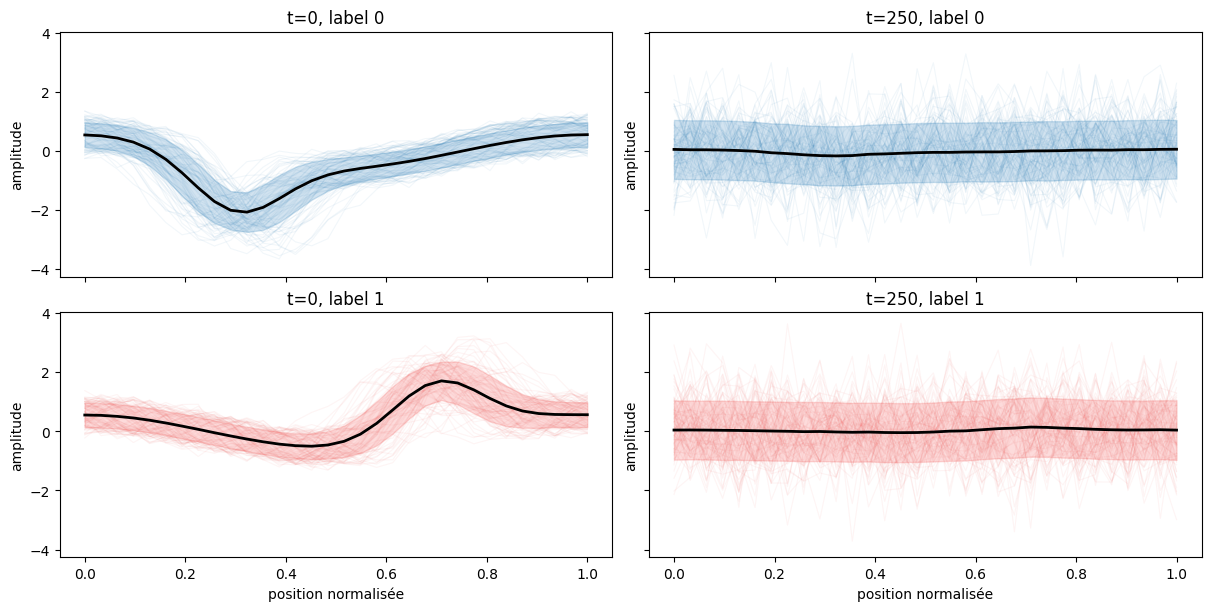

In [10]:
samples_tensor = torch.stack(samples)
mask0 = labels == 0
mask1 = labels == 1

fig, ax = plt.subplots(2, 2, figsize=(12, 6), sharex=True, sharey=True, constrained_layout=True)

for col, time_index in enumerate([0, TIME_STEPS]):
    for label_value, mask, color in [(0, mask0, COLORS[0]), (1, mask1, COLORS[1])]:
        subset = samples_tensor[time_index, mask]
        mean_signal = subset.mean(dim=0)
        std_signal = subset.std(dim=0)
        axis = ax[label_value, col]
        axis.plot(grid, subset[:80].T, color=color, alpha=0.06, linewidth=0.8)
        axis.plot(grid, mean_signal, color="black", linewidth=2)
        axis.fill_between(
            grid.numpy(),
            (mean_signal - std_signal).numpy(),
            (mean_signal + std_signal).numpy(),
            color=color,
            alpha=0.2,
        )
        axis.set_title(f"t={time_index}, label {label_value}")
        axis.set_ylabel("amplitude")

for axis in ax[-1, :]:
    axis.set_xlabel("position normalisée")

plt.show()


# Entrainement 
On se place dans un cas tres simple, ou le modele de diffusion en degradant d'abord les données d'exemple, puis essaye de les reconstruire depuis un exemple moins bruité, a chaque étape du processus de degradation. 
La loss utilisé ici sera un maximum de vraissemblance ("upper bound on the negative log likelihood" en anglais),
$$ L := \mathbb{E}_q \left[ - \log p(x_T) - \sum_{t=1}^{T} \log \frac{p_\theta(x_{t-1} \mid x_t)}{q(x_t \mid x_{t-1})} \right] $$
Ou la sortie du modele generatif ( probleme inverse ) a la forme de, 
$$ q(x_t | x_{t-1}) := \mathcal{N}(x_{t-1};\mu_{\theta}(x,t),\Sigma_{\theta}(x_t,t)) $$

Il est important de voir qu'ici on entraine 2 réseaux de neuronnes, $\mu_\theta$ et $\Sigma_\theta$ prennant comme entré un échantillon bruité $x_t$ a une itération t, et essayant de predire les parametre de la distribution de l'echantillon $x_{t-1}$. 

Intuitivement on entraine ces reseaux a prédire $x_{t-1}$ basé sur $x_t$, a savoir le terme $p_\theta(x_{t-1} \mid x_t)$ dans la loss, pour chaque étape de diffusion.

Les autres élement de la loss sont ici des élement théorique $q(x_{t-1} \mid x_t)$ assurant que la loss puisse devenir parfaitement nulle pour ce cas spécifique de 2 gaussiennes

In [11]:
import torch.nn.functional as F

input_dim = SIGNAL_SIZE + 2  # signal bruité + temps normalisé + label
hidden_dim = 128

eps_model = torch.nn.Sequential(
    torch.nn.Linear(input_dim, hidden_dim),
    torch.nn.SiLU(),
    torch.nn.Linear(hidden_dim, hidden_dim),
    torch.nn.SiLU(),
    torch.nn.Linear(hidden_dim, hidden_dim),
    torch.nn.SiLU(),
    torch.nn.Linear(hidden_dim, SIGNAL_SIZE),
)

optim = torch.optim.AdamW(
    eps_model.parameters(),
    lr=1e-3,
    weight_decay=1e-6,
)

def compute_loss(x0, labels, model):
    batch_size = x0.shape[0]

    t = torch.randint(
        1,
        TIME_STEPS + 1,
        (batch_size, 1),
        device=x0.device,
        dtype=x0.dtype,
    )

    alpha_bar = (1 - BETA) ** t
    eps = torch.randn_like(x0)

    xt = torch.sqrt(alpha_bar) * x0 + torch.sqrt(1 - alpha_bar) * eps

    xin = torch.cat(
        [
            xt,
            t / TIME_STEPS,
            labels[:, None].to(dtype=x0.dtype),
        ],
        dim=1,
    )

    eps_pred = model(xin)

    return F.mse_loss(eps_pred, eps)


In [12]:
from torch.utils.data import TensorDataset, DataLoader
from tqdm.auto import tqdm

train_loader = DataLoader(
    TensorDataset(dataset, labels),
    batch_size=256,
    shuffle=True,
)

loss_history = []

for epoch in range(100):

    pbar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/100",
        leave=False,
    )

    for x_batch, y_batch in pbar:

        optim.zero_grad()

        loss = compute_loss(
            x_batch,
            y_batch,
            eps_model,
        )

        loss.backward()
        optim.step()

        loss_history.append(loss.item())

        pbar.set_postfix(
            loss=f"{loss.item():.4f}"
        )


KeyboardInterrupt: 

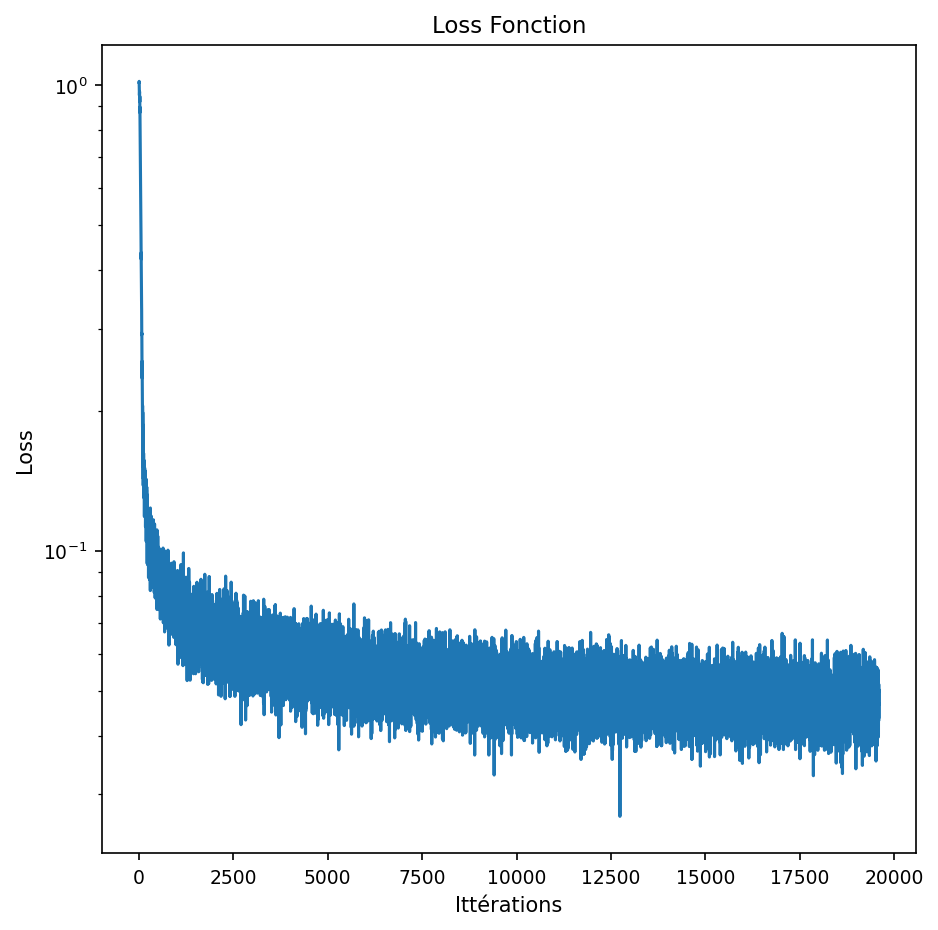

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(7, 7), sharex=True)
ax.plot(loss_history)
ax.set_yscale('log')
ax.set_ylabel('Loss')
ax.set_xlabel('Ittérations')
ax.set_title('Loss Fonction')
plt.show()

# Géneration de données

In [43]:
def sample_reverse(model, labels, steps=TIME_STEPS, beta=BETA):
    count = labels.shape[0]
    device = next(model.parameters()).device

    labels = labels.to(device)
    xt = torch.randn(count, SIGNAL_SIZE, device=device)
    sample_history = [xt.detach().cpu()]

    for t in range(steps, 0, -1):
        t_feature = torch.full(
            (count, 1),
            t / steps,
            device=device,
        )

        xin = torch.cat(
            [
                xt,
                t_feature,
                labels[:, None].float(),
            ],
            dim=1,
        )

        eps_pred = model(xin)

        alpha = 1 - beta
        alpha_bar = alpha ** t

        mean = (1 / np.sqrt(alpha)) * (
            xt - (beta / np.sqrt(1 - alpha_bar)) * eps_pred
        )

        if t > 1:
            noise = torch.randn_like(xt)
            xt = mean + np.sqrt(beta) * noise
        else:
            xt = mean

        sample_history.append(xt.detach().cpu())

    return torch.stack(sample_history)


In [44]:
labels0 = torch.zeros(5000, dtype=torch.long)
labels1 = torch.ones(5000, dtype=torch.long)

samples0 = sample_reverse(eps_model, labels0)
samples1 = sample_reverse(eps_model, labels1)

generated0 = samples0[-1]
generated1 = samples1[-1]


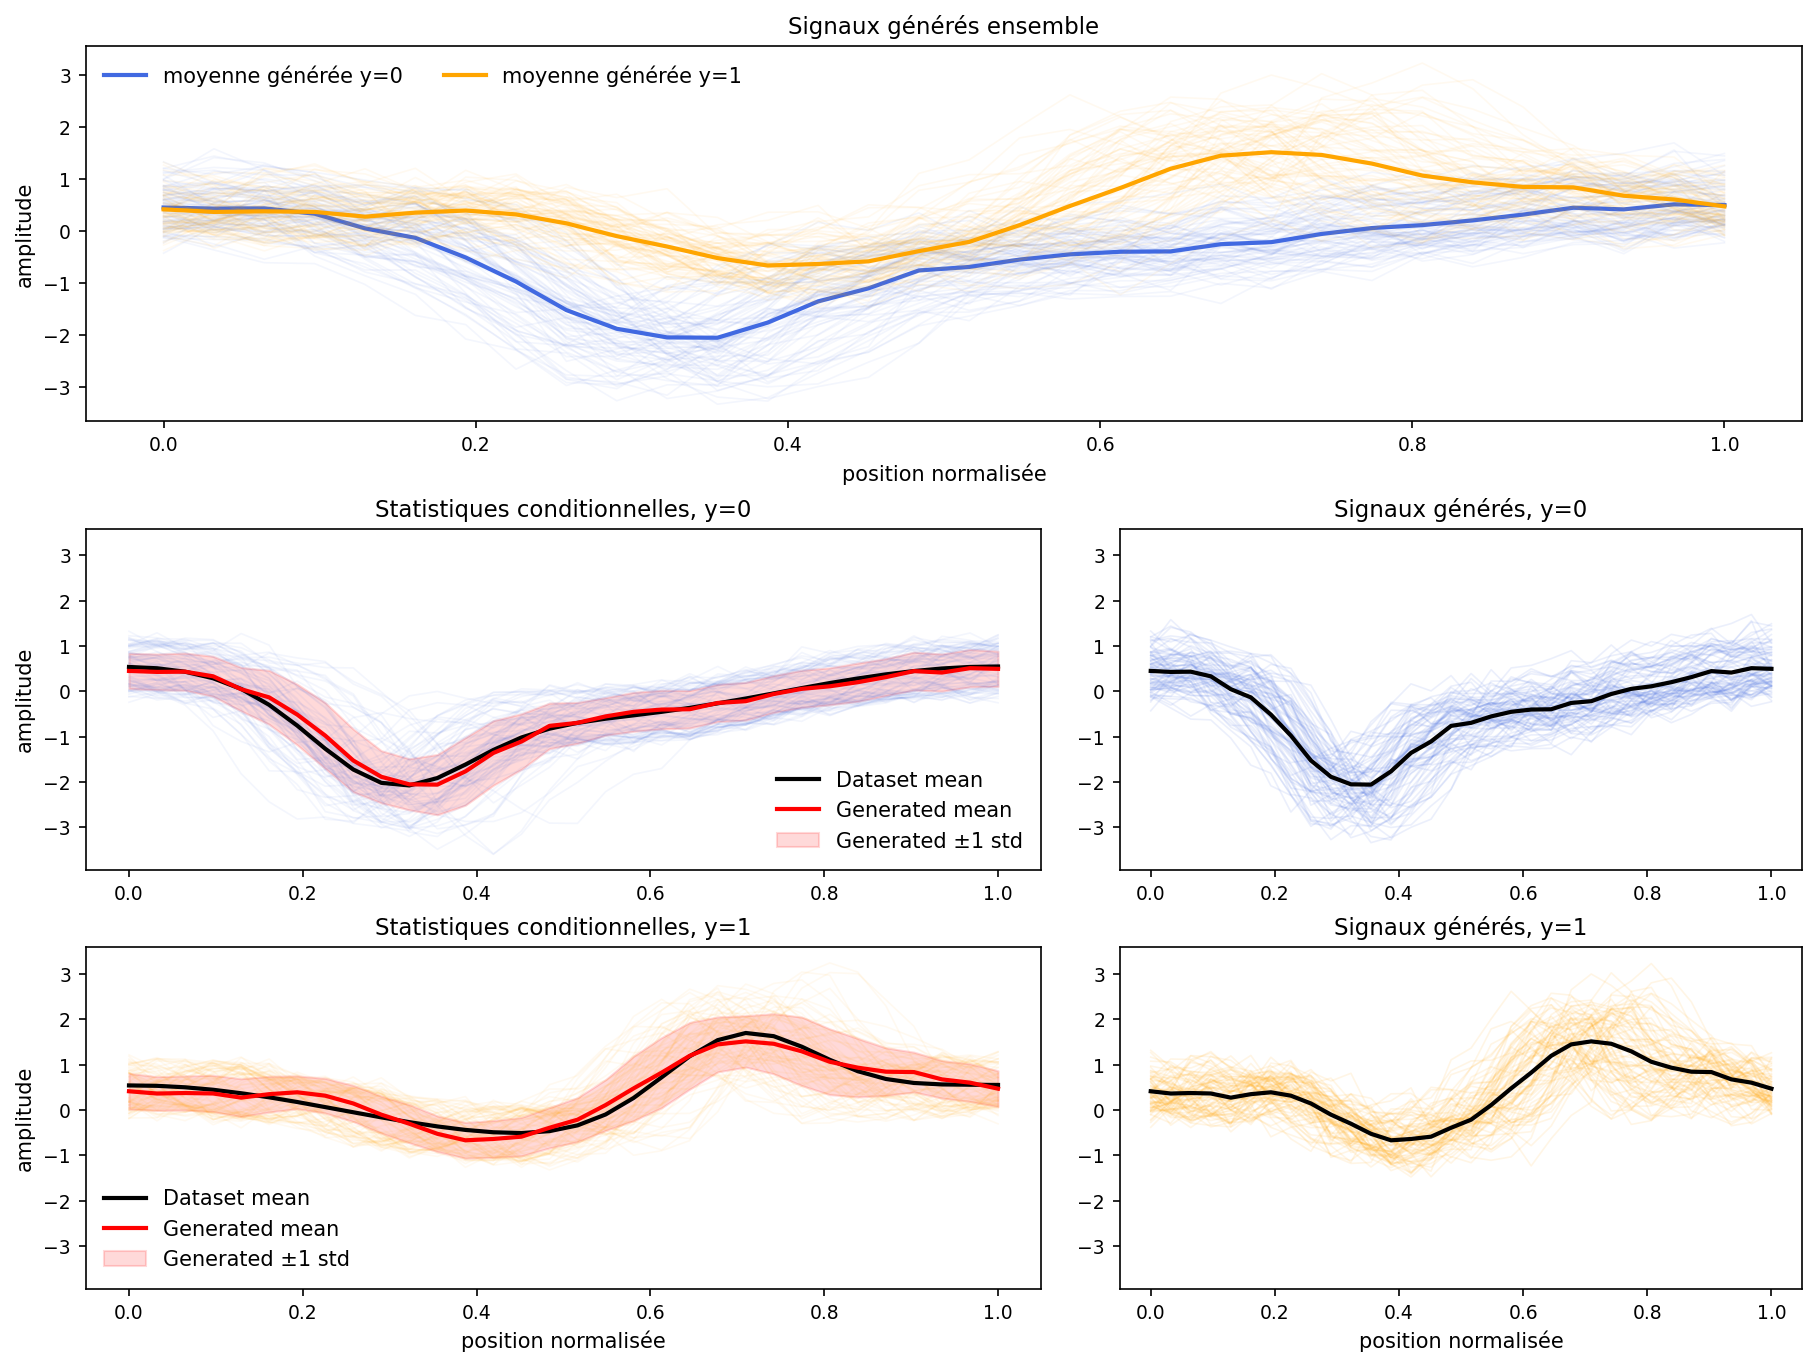

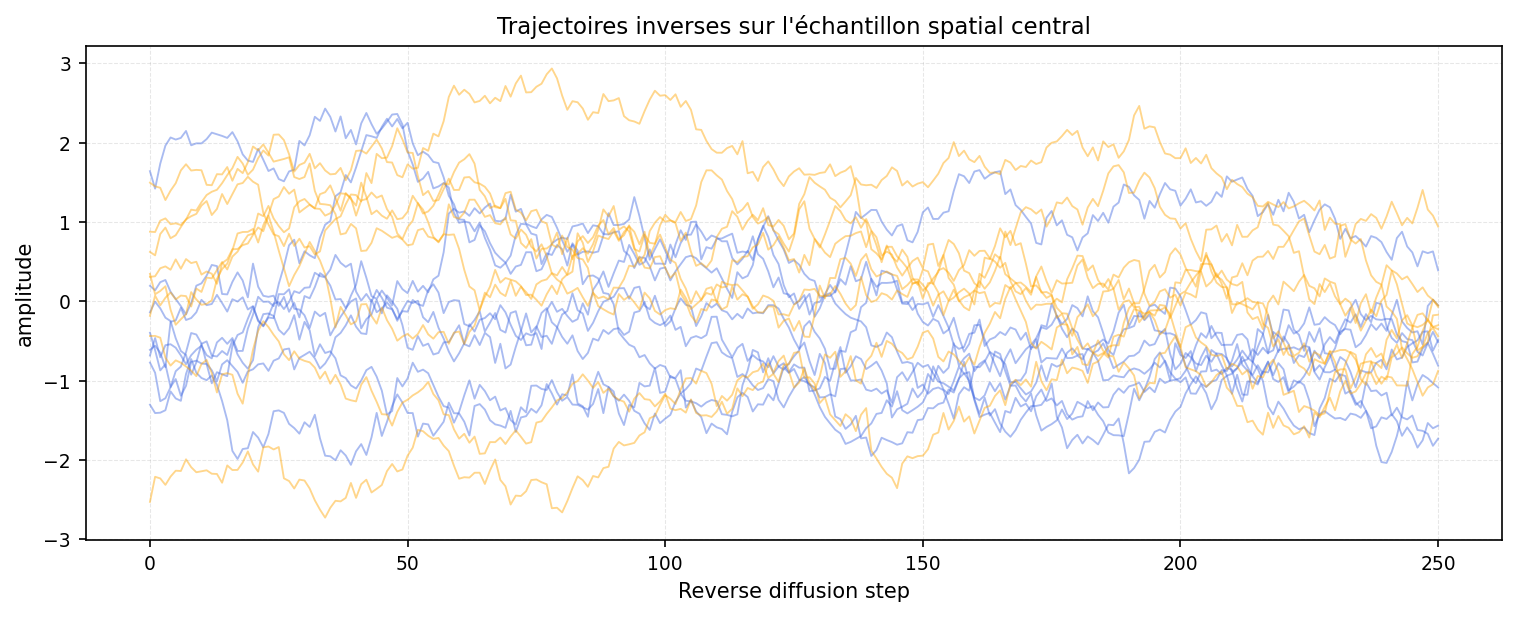

In [ ]:
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 150,
})

fig = plt.figure(figsize=(12, 9), constrained_layout=True)
gs = fig.add_gridspec(
    3,
    2,
    height_ratios=[1.1, 1.0, 1.0],
    width_ratios=[1.4, 1.0],
)

ax_all = fig.add_subplot(gs[0, :])
ax_stats_0 = fig.add_subplot(gs[1, 0])
ax_generated_0 = fig.add_subplot(gs[1, 1], sharex=ax_stats_0, sharey=ax_stats_0)
ax_stats_1 = fig.add_subplot(gs[2, 0], sharex=ax_stats_0, sharey=ax_stats_0)
ax_generated_1 = fig.add_subplot(gs[2, 1], sharex=ax_stats_0, sharey=ax_stats_0)

stats_axes = {0: ax_stats_0, 1: ax_stats_1}
generated_axes = {0: ax_generated_0, 1: ax_generated_1}
generated_by_label = {0: generated0, 1: generated1}
colors = {0: "royalblue", 1: "orange"}

for label_value in [0, 1]:
    generated = generated_by_label[label_value]
    color = colors[label_value]

    ax_all.plot(grid, generated[:80].T, color=color, alpha=0.06, linewidth=0.8)
    ax_all.plot(
        grid,
        generated.mean(dim=0),
        color=color,
        linewidth=2,
        label=f"moyenne générée y={label_value}",
    )

for label_value in [0, 1]:
    generated = generated_by_label[label_value]
    real = dataset[labels == label_value]
    color = colors[label_value]

    ax_stats = stats_axes[label_value]
    ax_stats.plot(grid, real[:80].T, color=color, alpha=0.06, linewidth=0.8)
    ax_stats.plot(grid, real.mean(dim=0), color="black", linewidth=2, label="Dataset mean")
    ax_stats.plot(grid, generated.mean(dim=0), color="red", linewidth=2, label="Generated mean")
    ax_stats.fill_between(
        grid.numpy(),
        (generated.mean(dim=0) - generated.std(dim=0)).numpy(),
        (generated.mean(dim=0) + generated.std(dim=0)).numpy(),
        color="red",
        alpha=0.15,
        label="Generated ±1 std",
    )
    ax_stats.set_title(f"Statistiques conditionnelles, y={label_value}")
    ax_stats.set_ylabel("amplitude")
    ax_stats.legend(frameon=False)

    ax_generated = generated_axes[label_value]
    ax_generated.plot(grid, generated[:80].T, color=color, alpha=0.10, linewidth=0.8)
    ax_generated.plot(grid, generated.mean(dim=0), color="black", linewidth=2)
    ax_generated.set_title(f"Signaux générés, y={label_value}")

ax_all.set_title("Signaux générés ensemble")
ax_all.set_ylabel("amplitude")
ax_all.set_xlabel("position normalisée")
ax_all.legend(frameon=False, ncols=2)

ax_stats_1.set_xlabel("position normalisée")
ax_generated_1.set_xlabel("position normalisée")

plt.show()